In [1]:
# Import necessary packages
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("..")
from hy2dl.aux_functions.functions_evaluation import nse

In [2]:
color_palette = {"LSTM": "#4daf4a",
                 "MTS": "#ff7f00",
                 "sMTS": "#984ea3",
                 "benchmark": "#377eb8"}

Part 1. Performance comparison against Gauch et al., (2021)

**References:**
[1]: Gauch, M., Kratzert, F., Klotz, D., Nearing, G., Lin, J., & Hochreiter, S. (2021). Rainfall–runoff prediction at multiple timescales with a single Long Short-Term Memory network. Hydrology and Earth System Sciences, 25(4), 2045–2062. https://doi.org/10.5194/hess-25-2045-2021

In [ ]:
# First experiment: Same number of inputs for daily and hourly data.

# # Read the results generated by Gauch et al. (2021)
# df_NSE_MTS = pd.read_csv("CAMELS_US_hourly/NSE_MTS_benchmark.csv", index_col="basin_id", dtype={"basin_id": str})
# df_NSE_sMTS = pd.read_csv("CAMELS_US_hourly/NSE_sMTS_benchmark.csv", index_col="basin_id", dtype={"basin_id": str})
# df_NSE_Naive= pd.read_csv("CAMELS_US_hourly/NSE_Naive_benchmark.csv", index_col="basin_id", dtype={"basin_id": str})

# Read the results generated using Hy2DL
path_results_LSTM = ["/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_110/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_111/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_222/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_333/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_444/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_555/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_666/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_777/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_888/test_results_best_epoch/",
                     "/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/results/US_exp1/1_days_seed_999/test_results_best_epoch/"
                     ]


# Read information produced by ensemble of LSTMs and store it in dictionary of dataframes
lstm_results = {}
for i, ensemble_member in enumerate(path_results_LSTM):
    with open(ensemble_member + "/test_results.pickle", "rb") as f:
        info_lstm = pickle.load(f)
    # Iterate over each basin
    for basin in info_lstm.keys():
        y_sim = info_lstm[basin]["y_sim"]
        if i == 0: # If this is the first ensemble member, initialize the DataFrame with y_obs and y_sim
            y_obs = info_lstm[basin]["y_obs"]
            lstm_results[basin] = pd.DataFrame(data={"y_obs": y_obs, f"y_sim_ens_{i+1}": y_sim}, index=y_obs.index)
        else: # For subsequent ensemble members, add y_sim as a new column
            lstm_results[basin][f"y_sim_ens_{i+1}"] = y_sim
# Calculate the median of the simulated values and add it as a new column
for basin in lstm_results.keys():
    # Select only the y_sim columns
    y_sim_columns = [col for col in lstm_results[basin].columns if col.startswith("y_sim_ens_")]
    lstm_results[basin]["y_sim"] = lstm_results[basin][y_sim_columns].median(axis=1)
    

df_NSE_lstm_CAMELS_US_hourly = pd.DataFrame(data={"basin_id": list(lstm_results.keys()), 
                                                  "LSTM": np.round(nse(df_results=lstm_results, average=False),3)}
                                                  ).set_index("basin_id")

# df_NSE_comparison_exp1 = pd.concat([df_NSE_lstm_CAMELS_US_hourly, df_NSE_MTS, df_NSE_sMTS, df_NSE_Naive], axis=1)
# df_NSE_comparison_exp1 = df_NSE_comparison_exp1.apply(lambda x: x.sort_values().values).reset_index(drop=True)
# df_NSE_comparison_exp1["cdf"] = np.arange(len(df_NSE_comparison_exp1)) / (len(df_NSE_comparison_exp1) - 1)

In [ ]:
# # Second experiment: Different number of inputs for daily and hourly data.

# # Read the results generated by Gauch et al. (2021)
# df_NSE_gauch = pd.read_csv("CAMELS_US_hourly/NSE_MTS_multipleforcing_benchmark.csv", index_col="basin_id", 
#                            dtype={"basin_id": str})

# # Read the results generated using Hy2DL
# path_results_LSTM_multipleforcings = ["CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_110",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_111",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_222",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_333",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_444",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_555",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_666",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_777",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_888",
#                                       "CAMELS_US_hourly/MFLSTM_hourly_us_multipleforcings_seed_999"]


# # Read information produced by ensemble of LSTMs and store it in dictionary of dataframes
# lstm_results = {}
# for i, ensemble_member in enumerate(path_results_LSTM_multipleforcings):
#     with open(ensemble_member + "/test_results.pickle", "rb") as f:
#         info_lstm = pickle.load(f)
#     # Iterate over each basin
#     for basin in info_lstm.keys():
#         y_sim = info_lstm[basin]["y_sim"]
#         if i == 0: # If this is the first ensemble member, initialize the DataFrame with y_obs and y_sim
#             y_obs = info_lstm[basin]["y_obs"]
#             lstm_results[basin] = pd.DataFrame(data={"y_obs": y_obs, f"y_sim_ens_{i+1}": y_sim}, index=y_obs.index)
#         else: # For subsequent ensemble members, add y_sim as a new column
#             lstm_results[basin][f"y_sim_ens_{i+1}"] = y_sim
# # Calculate the mean of the simulated values and add it as a new column
# for basin in lstm_results.keys():
#     # Select only the y_sim columns
#     y_sim_columns = [col for col in lstm_results[basin].columns if col.startswith("y_sim_ens_")]
#     lstm_results[basin]["y_sim"] = lstm_results[basin][y_sim_columns].median(axis=1)

# df_NSE_lstm_CAMELS_US_hourly = pd.DataFrame(data={"basin_id": list(lstm_results.keys()), 
#                                                   "LSTM": np.round(nse(df_results=lstm_results, average=False),3)}
#                                                   ).set_index("basin_id")

# df_NSE_comparison_exp2 = pd.concat([df_NSE_lstm_CAMELS_US_hourly, df_NSE_gauch], axis=1)
# df_NSE_comparison_exp2 = df_NSE_comparison_exp2.apply(lambda x: x.sort_values().values).reset_index(drop=True)
# df_NSE_comparison_exp2["cdf"] = np.arange(len(df_NSE_comparison_exp2)) / (len(df_NSE_comparison_exp2) - 1)

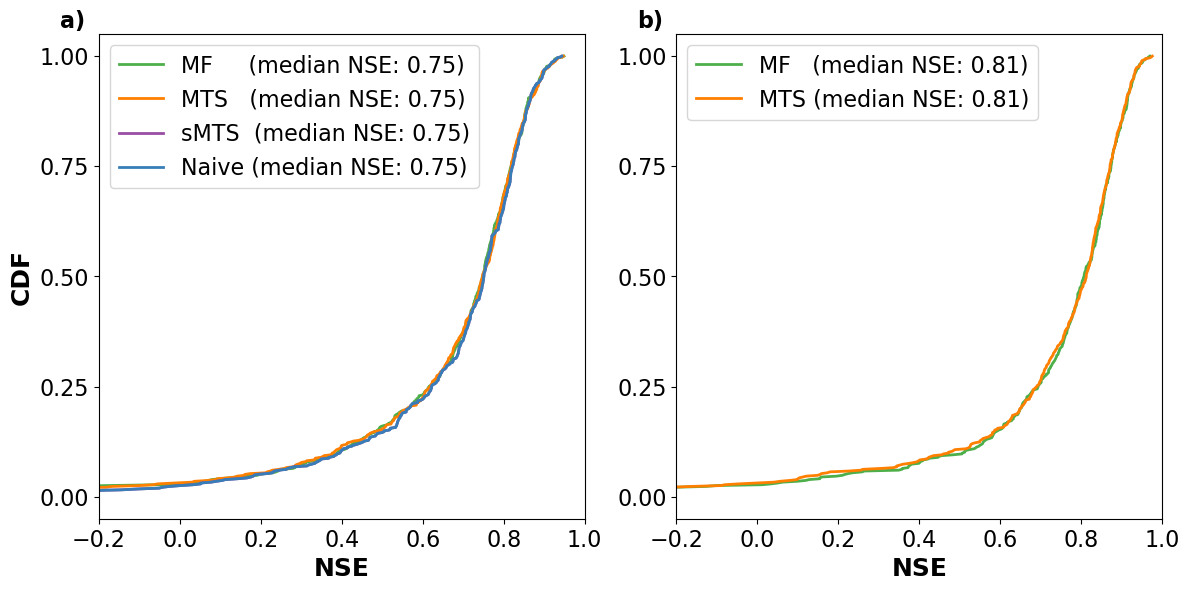

In [41]:
# Create a 2x1 subplot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First subplot
axs[0].plot(
    df_NSE_comparison_exp1["LSTM"],
    df_NSE_comparison_exp1["cdf"],
    linewidth=2,
    label=f"MF     (median NSE: {df_NSE_comparison_exp1['LSTM'].median():.2f})",
    color=color_palette["LSTM"],
)
axs[0].plot(
    df_NSE_comparison_exp1["Benchmark_MTS"],
    df_NSE_comparison_exp1["cdf"],
    linewidth=2,
    label=f"MTS   (median NSE: {df_NSE_comparison_exp1["Benchmark_MTS"].median():.2f})",
    color=color_palette["MTS"],
)
axs[0].plot(
    df_NSE_comparison_exp1["Benchmark_sMTS"],
    df_NSE_comparison_exp1["cdf"],
    linewidth=2,
    label=f"sMTS  (median NSE: {df_NSE_comparison_exp1["Benchmark_sMTS"].median():.2f})",
    color=color_palette["sMTS"],
)
axs[0].plot(
    df_NSE_comparison_exp1["Benchmark_Naive"],
    df_NSE_comparison_exp1["cdf"],
    linewidth=2,
    label=f"Naive (median NSE: {df_NSE_comparison_exp1["Benchmark_Naive"].median():.2f})",
    color=color_palette["benchmark"],
)

# Set limits and labels for the first subplot
axs[0].set_xlim(-0.2, 1)
axs[0].set_xlabel("NSE", fontsize=18, fontweight="bold")
axs[0].set_ylabel("CDF", fontsize=18, fontweight="bold")
axs[0].tick_params(axis="both", labelsize=16)  # Set tick label size for both axes
axs[0].set_yticks(np.arange(0, 1.25, 0.25))  # Set y-ticks from 0 to 1 in increments of 0.25
axs[0].legend(loc="upper left", fontsize=16)
axs[0].text(-0.08, 1.05, "a)", transform=axs[0].transAxes, fontsize=16, fontweight="bold", verticalalignment="top")

# Second subplot
axs[1].plot(
    df_NSE_comparison_exp2["LSTM"],
    df_NSE_comparison_exp2["cdf"],
    linewidth=2,
    label=f"MF   (median NSE: {df_NSE_comparison_exp2["LSTM"].median():.2f})",
    color=color_palette["LSTM"],
)
axs[1].plot(
    df_NSE_comparison_exp2["Benchmark_MTS_multipleforcings"],
    df_NSE_comparison_exp2["cdf"],
    linewidth=2,
    label=f"MTS (median NSE: {df_NSE_comparison_exp2['Benchmark_MTS_multipleforcings'].median():.2f})",
    color=color_palette["MTS"],
)

# Set limits and labels for the second subplot
axs[1].set_xlim(-0.2, 1)
axs[1].set_xlabel("NSE", fontsize=18, fontweight="bold")
axs[1].tick_params(axis="both", labelsize=16)  # Set tick label size for both axes
axs[1].set_yticks(np.arange(0, 1.25, 0.25))  # Set y-ticks from 0 to 1 in increments of 0.25
axs[1].legend(loc="upper left", fontsize=16)
axs[1].text(-0.08, 1.05, "b)", transform=axs[1].transAxes, fontsize=16, fontweight="bold", verticalalignment="top")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig("fig02.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

In [37]:
# Third experiment: Weekly-daily-hourly data
# Dictionary to store DataFrames
dfs = {}
# Loop through each path
for i, ensemble_member in enumerate(path_results_LSTM):
    df = pd.read_csv(ensemble_member + "/NSE_testing.csv", index_col="basin_id", dtype={"basin_id": str})
    df.columns = [f"NSE_ens_{i}"]
    dfs[ensemble_member] = df

# To concatenate all DataFrames into one
df_NSE_comparison_exp3 = pd.concat(dfs.values(), axis=1)

# Read weekly-daily-hourly data
df = pd.read_csv("CAMELS_US_hourly/MFLSTM_hourly_us_3freq_seed_110/NSE_testing.csv", index_col="basin_id", 
                 dtype={"basin_id": str})
df.columns = ["NSE_3freq"]


df_NSE_comparison_exp3 = pd.concat([df_NSE_comparison_exp3, df], axis=1)
df_NSE_comparison_exp3 = df_NSE_comparison_exp3.apply(lambda x: x.sort_values().values).reset_index(drop=True)
df_NSE_comparison_exp3["cdf"] = np.arange(len(df_NSE_comparison_exp3)) / (len(df_NSE_comparison_exp3) - 1)

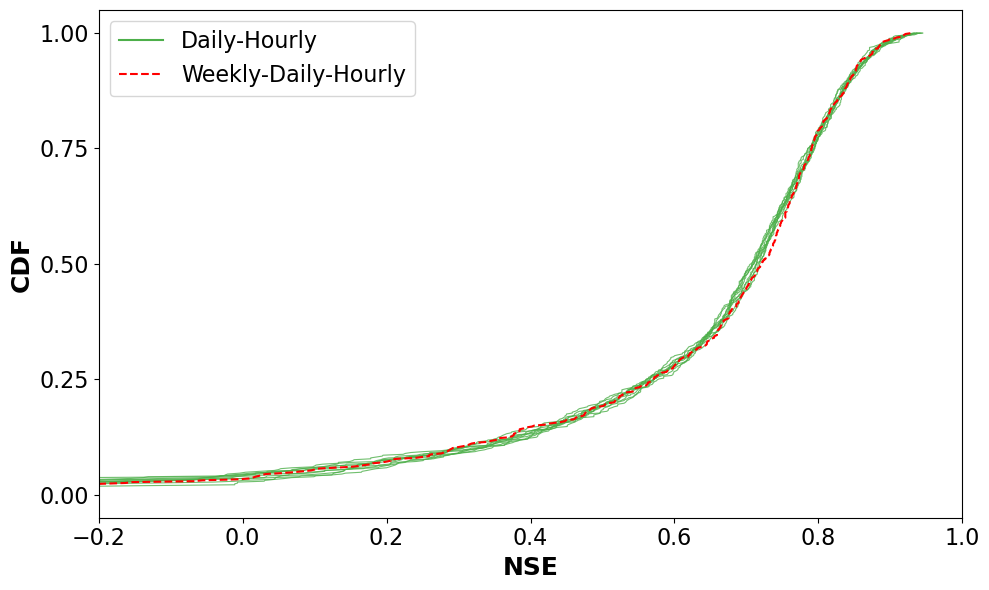

In [55]:
ensemble_member = [col for col in df_NSE_comparison_exp3.columns if col.startswith("NSE_ens_")]

plt.figure(figsize=(10, 6))

#Daily-hourly 
for col in ensemble_member:
    plt.plot(df_NSE_comparison_exp3[col], 
             df_NSE_comparison_exp3["cdf"],
             alpha=0.8,
             linewidth=0.8,
             color=color_palette["LSTM"])
plt.plot([], color=color_palette["LSTM"], label="Daily-Hourly")

# Weekly-daily-hourly
plt.plot(df_NSE_comparison_exp3["NSE_3freq"], 
            df_NSE_comparison_exp3["cdf"],
            color="r",
            linestyle="--",
            label="Weekly-Daily-Hourly")
    
# Format plot
plt.xlim(-0.2, 1)
plt.xlabel("NSE", fontsize=18, fontweight="bold")
plt.ylabel("CDF", fontsize=18, fontweight="bold")
plt.tick_params(axis="both", labelsize=16)  # Set tick label size for both axes
plt.yticks(np.arange(0, 1.25, 0.25))  # Set y-ticks from 0 to 1 in increments of 0.25
plt.legend(loc="upper left", fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout()
# Show plot
plt.savefig("figC1.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()

In [39]:
average_median_ensembles = np.mean(df_NSE_comparison_exp3[ensemble_member].median().values)
median_weeklydailyhourly = df_NSE_comparison_exp3["NSE_3freq"].median()
print(f"The average median for the 10 ensemble members, for daily-hourly experiment: {average_median_ensembles:.3f}")
print(f"Median for the weekly-daily-hourly experiment: {median_weeklydailyhourly:.3f}")

The average median for the 10 ensemble members, for daily-hourly experiment: 0.712
Median for the weekly-daily-hourly experiment: 0.720
